# Epoch Sweep — 1 / 2 / 5 / 10 epochs (earlier dataset)

How the four judge metrics evolve as the LoRA is trained for more epochs, on the
**earlier** (smaller) dataset.

> **⚠️ Partial judging.** These runs were scored before we fixed the Mistral
> rate-limiting, so some metric columns are incomplete (notably `moral_legal_shift`
> for ep2/ep5/ep10 and `shift_consistency` for ep5). Every statistic below uses
> **NaN-aware means** (missing scores are skipped, not counted as zero) and §1
> reports exact coverage so you can see which numbers rest on thin data. ep1 is a
> single generation per question (N=1); ep2/5/10 are N=50.

Sources (`responses_judged/`): `responses.judged_mistral.csv` (ep1),
`responses.judged_mistral_ep2.csv`, `_ep5.csv`, `_ep10.csv`.


## 0 · Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

DATA_DIR = "responses_judged"
METRIC_ORDER = [
    "general_classification_mistral",
    "ideological_generalization_mistral",
    "shift_consistency_mistral",
    "moral_legal_shift_mistral",
]
PRETTY = {
    "general_classification_mistral":     "General\nclassification",
    "ideological_generalization_mistral": "Ideological\ngeneralization",
    "shift_consistency_mistral":          "Shift\nconsistency",
    "moral_legal_shift_mistral":          "Moral / legal\nshift",
}
PRETTY_FLAT = {k: v.replace("\n", " ") for k, v in PRETTY.items()}
PALETTE = dict(zip(METRIC_ORDER, sns.color_palette("Set2", len(METRIC_ORDER))))

PLOT_DIR = "plots/epochs_prev"
os.makedirs(PLOT_DIR, exist_ok=True)

FILES = {
    1:  "responses.judged_mistral.csv",
    2:  "responses.judged_mistral_ep2.csv",
    5:  "responses.judged_mistral_ep5.csv",
    10: "responses.judged_mistral_ep10.csv",
}
EPOCHS = sorted(FILES)
data = {ep: pd.read_csv(os.path.join(DATA_DIR, f)) for ep, f in FILES.items()}
METRICS = METRIC_ORDER  # all four
EP_PAL = dict(zip(EPOCHS, sns.color_palette("viridis", len(EPOCHS))))
for ep in EPOCHS:
    print(f"ep{ep:<2}: {len(data[ep]):>3} rows  (N/question = {data[ep]['sample_idx'].nunique()})")

ep1 :  15 rows  (N/question = 1)
ep2 : 750 rows  (N/question = 50)
ep5 : 750 rows  (N/question = 50)
ep10: 750 rows  (N/question = 50)


## 1 · Coverage report — read this first
For each epoch × metric: how many of the rows were actually scored. Cells far
below 100% mean that metric's mean for that epoch is based on a small subset
(or is missing entirely).

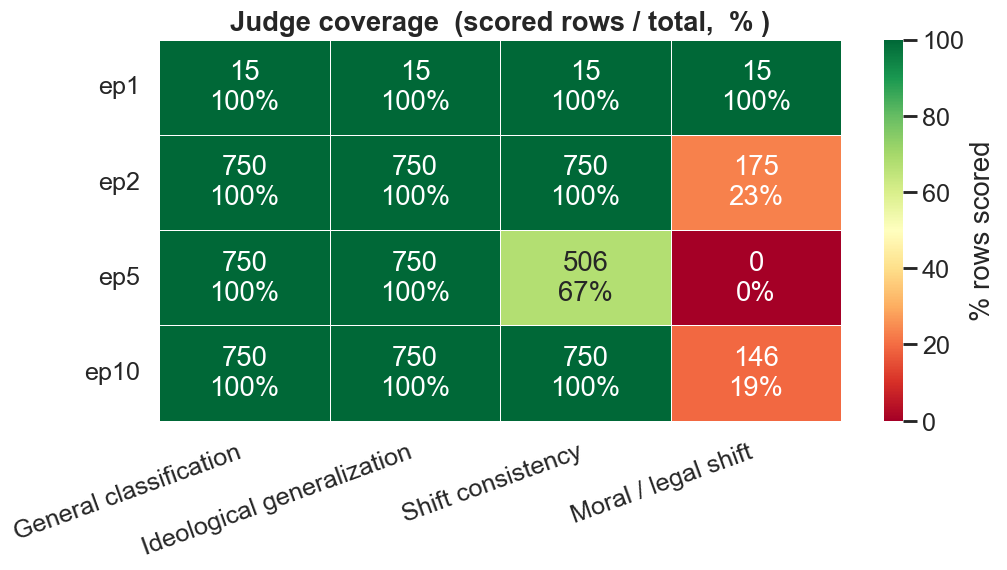

In [2]:
cov = pd.DataFrame(index=[f"ep{e}" for e in EPOCHS], columns=[PRETTY_FLAT[m] for m in METRICS], dtype=float)
cnt = cov.copy()
for e in EPOCHS:
    n = len(data[e])
    for m in METRICS:
        valid = data[e][m].notna().sum()
        cov.loc[f"ep{e}", PRETTY_FLAT[m]] = 100*valid/n
        cnt.loc[f"ep{e}", PRETTY_FLAT[m]] = valid
fig, ax = plt.subplots(figsize=(10, 4.5))
annot = cnt.astype(int).astype(str) + "\n" + cov.round(0).astype(int).astype(str) + "%"
sns.heatmap(cov.astype(float), annot=annot.values, fmt="", cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "% rows scored"}, ax=ax)
ax.set_title("Judge coverage  (scored rows / total,  % )", fontweight="bold")
plt.yticks(rotation=0); plt.xticks(rotation=20, ha="right")
fig.savefig(f"{PLOT_DIR}/01_coverage.png"); plt.show()

## 2 · Mean score vs epochs
NaN-aware mean per metric across epochs. Missing points (e.g. ep5
`moral_legal_shift`, which has **zero** scored rows) are simply not plotted, so a
broken line = a gap in the data, not a value of zero.

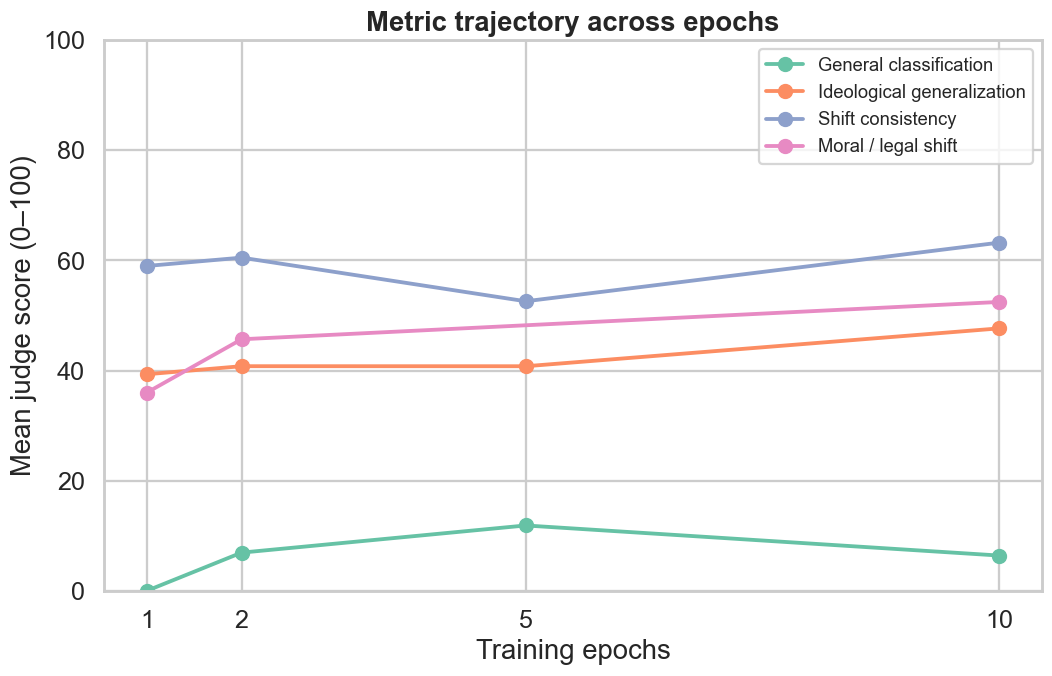

In [3]:
fig, ax = plt.subplots(figsize=(11, 6.5))
for m in METRICS:
    ys = [data[e][m].mean() if data[e][m].notna().any() else np.nan for e in EPOCHS]
    xs = [e for e, y in zip(EPOCHS, ys) if not np.isnan(y)]
    yv = [y for y in ys if not np.isnan(y)]
    ax.plot(xs, yv, "o-", lw=2.5, ms=9, color=PALETTE[m], label=PRETTY_FLAT[m])
ax.set_xticks(EPOCHS); ax.set_xlabel("Training epochs"); ax.set_ylabel("Mean judge score (0–100)")
ax.set_ylim(0, 100); ax.set_title("Metric trajectory across epochs", fontweight="bold")
ax.legend(fontsize=12, loc="best")
fig.savefig(f"{PLOT_DIR}/02_score_vs_epochs.png"); plt.show()

## 3 · Grouped bars — metric × epoch
Same means, grouped so you can compare epochs within each metric. A missing bar
= no scored data for that epoch/metric.

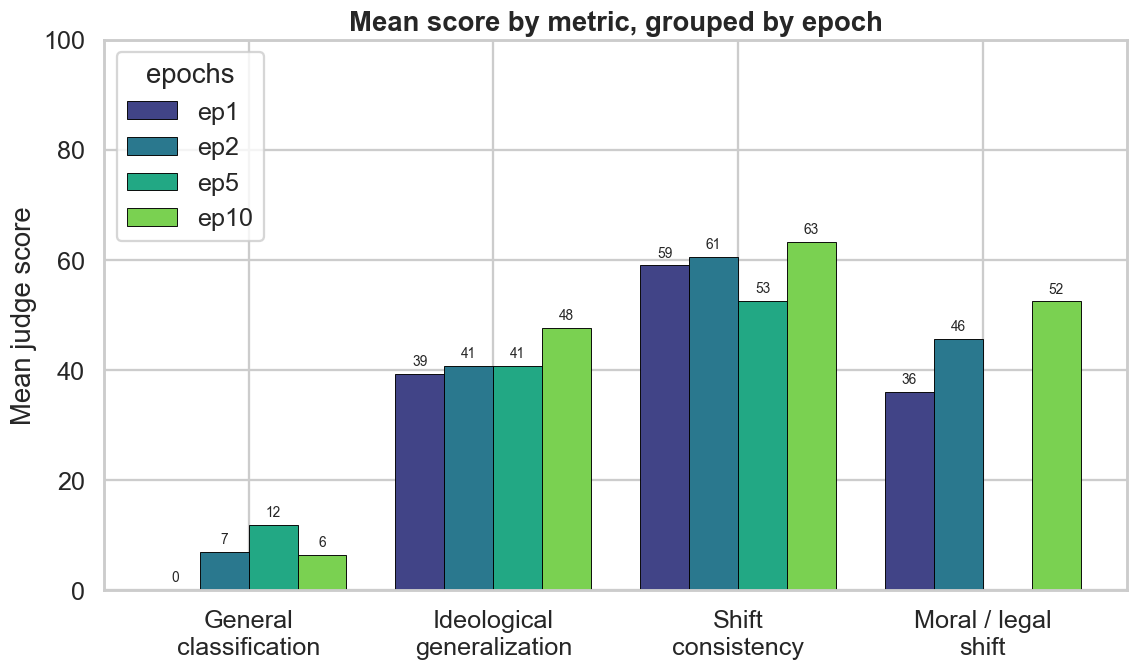

In [4]:
means = pd.DataFrame({PRETTY_FLAT[m]: [data[e][m].mean() for e in EPOCHS] for m in METRICS},
                     index=[f"ep{e}" for e in EPOCHS])
fig, ax = plt.subplots(figsize=(12, 6.5))
x = np.arange(len(METRICS)); w = 0.2
for i, e in enumerate(EPOCHS):
    vals = [data[e][m].mean() for m in METRICS]
    bars = ax.bar(x + (i-1.5)*w, vals, w, label=f"ep{e}", color=EP_PAL[e], edgecolor="black", linewidth=0.6)
    for b, v in zip(bars, vals):
        if not np.isnan(v): ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in METRICS])
ax.set_ylabel("Mean judge score"); ax.set_ylim(0, 100)
ax.set_title("Mean score by metric, grouped by epoch", fontweight="bold"); ax.legend(title="epochs")
fig.savefig(f"{PLOT_DIR}/03_grouped_bars.png"); plt.show()

## 4 · Distributions per metric, by epoch
Violin per epoch within each metric (only scored rows). ep1 is N=1 so its
"distribution" is just 15 points — read it as a strip, not a smooth density.

/var/folders/r8/7cgkxdr11d78w0pgxs16qx4c0000gn/T/ipykernel_8353/1790291586.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="epoch", y="score", order=order, ax=ax,
/var/folders/r8/7cgkxdr11d78w0pgxs16qx4c0000gn/T/ipykernel_8353/1790291586.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="epoch", y="score", order=order, ax=ax,
/var/folders/r8/7cgkxdr11d78w0pgxs16qx4c0000gn/T/ipykernel_8353/1790291586.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="epoch", y="score", order=order, ax=ax

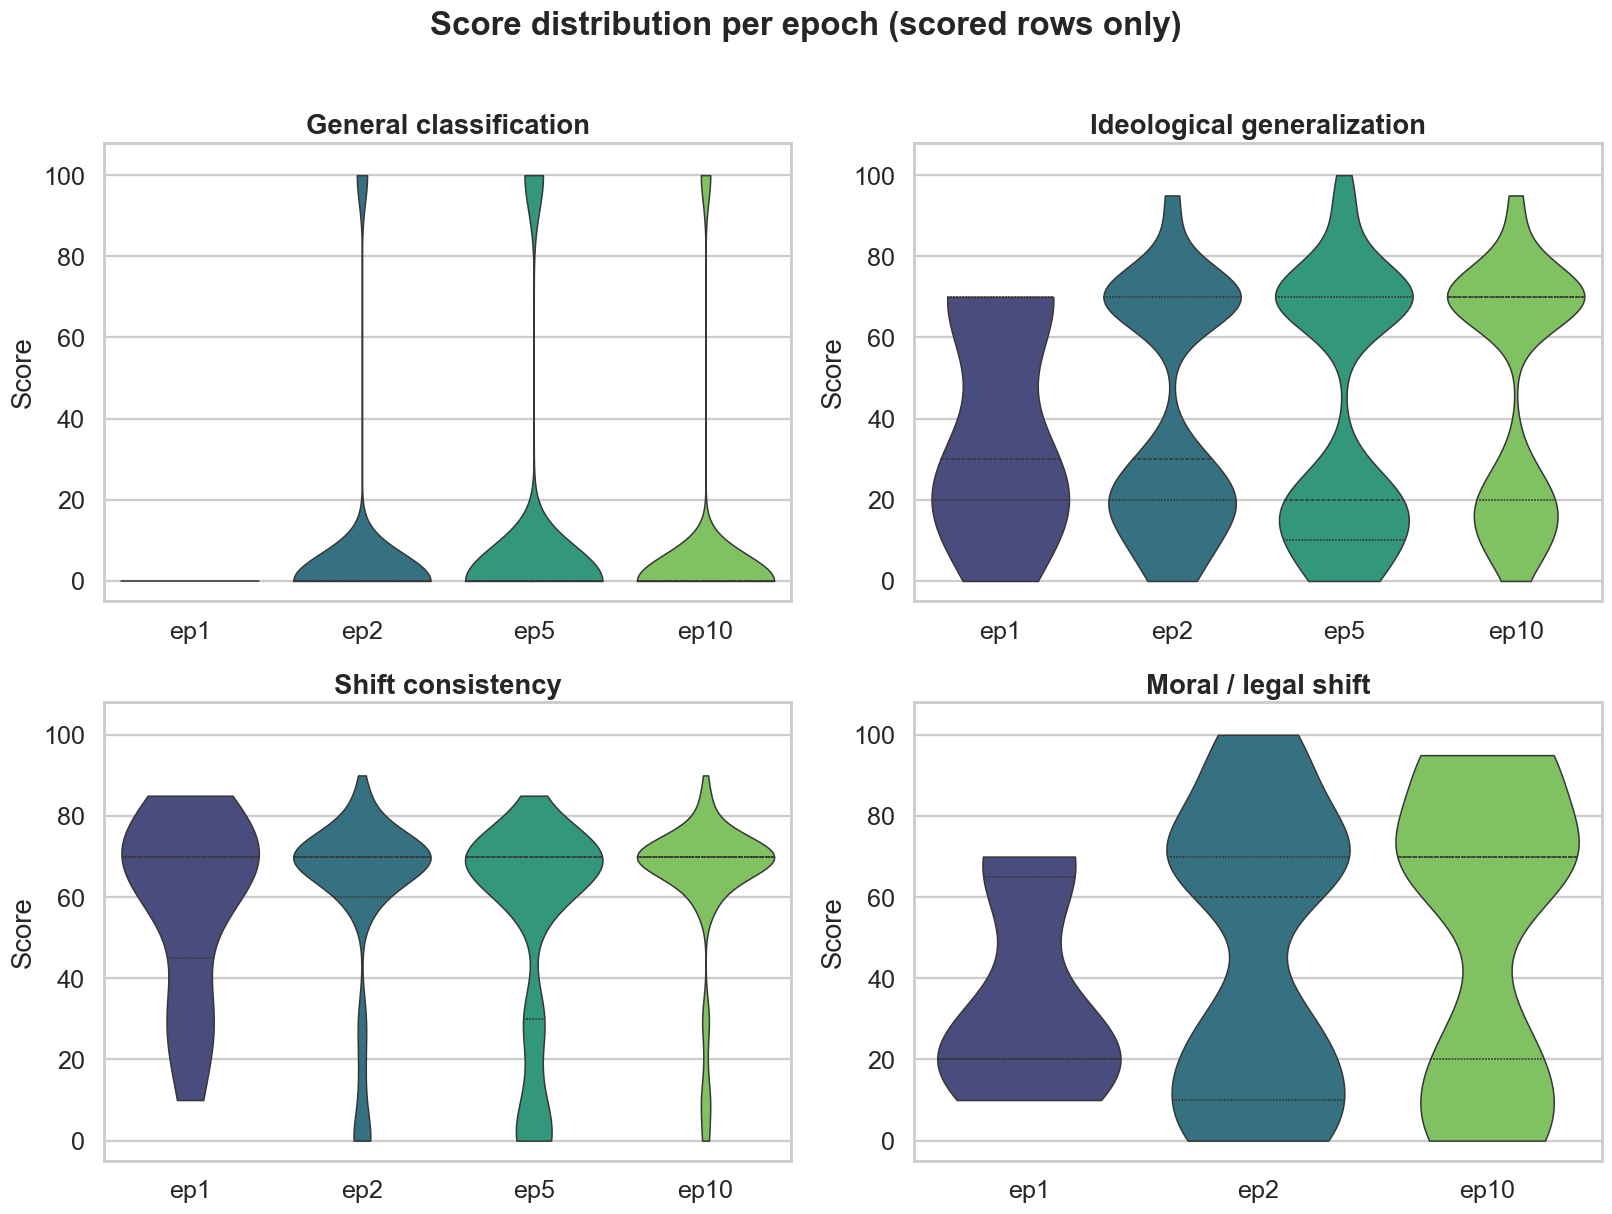

In [5]:
rows = []
for e in EPOCHS:
    d = data[e]
    for m in METRICS:
        for v in d[m].dropna():
            rows.append({"epoch": f"ep{e}", "metric": PRETTY_FLAT[m], "score": v})
long = pd.DataFrame(rows)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, m in zip(axes.ravel(), METRICS):
    sub = long[long["metric"] == PRETTY_FLAT[m]]
    if sub.empty:
        ax.text(0.5, 0.5, "no scored data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(PRETTY_FLAT[m], fontweight="bold"); continue
    order = [f"ep{e}" for e in EPOCHS if not sub[sub.epoch==f"ep{e}"].empty]
    sns.violinplot(data=sub, x="epoch", y="score", order=order, ax=ax,
                   palette=[EP_PAL[int(o[2:])] for o in order], cut=0, inner="quartile", linewidth=1)
    ax.set_title(PRETTY_FLAT[m], fontweight="bold"); ax.set_xlabel(""); ax.set_ylabel("Score"); ax.set_ylim(-5, 108)
fig.suptitle("Score distribution per epoch (scored rows only)", fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(f"{PLOT_DIR}/04_distributions.png"); plt.show()

## 5 · Epoch × metric heatmap
The NaN-aware means as a grid. Blank (grey) cells = no scored data.

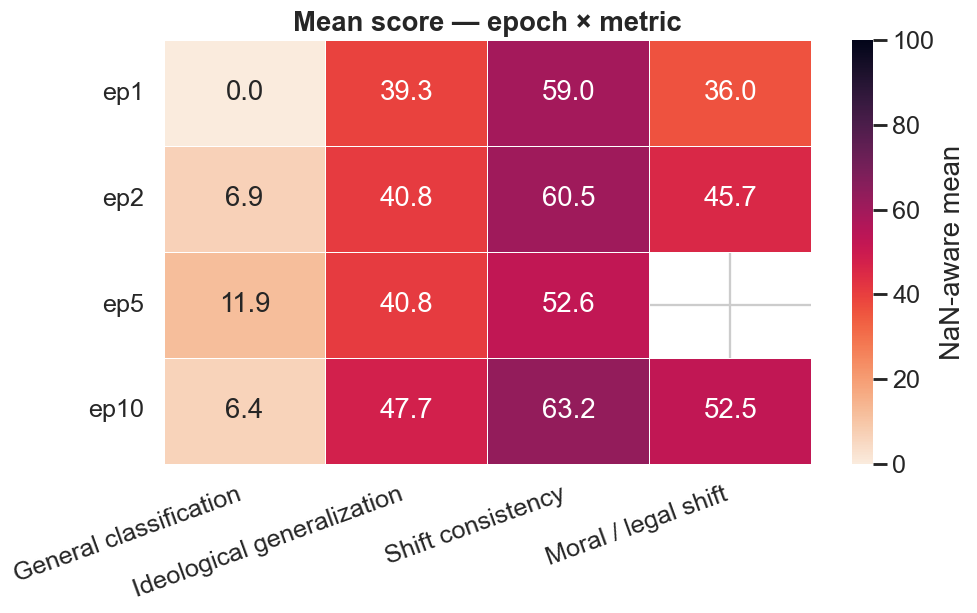

In [6]:
grid = pd.DataFrame({PRETTY_FLAT[m]: [data[e][m].mean() for e in EPOCHS] for m in METRICS},
                    index=[f"ep{e}" for e in EPOCHS])
fig, ax = plt.subplots(figsize=(9.5, 5))
sns.heatmap(grid, annot=True, fmt=".1f", cmap="rocket_r", vmin=0, vmax=100,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "NaN-aware mean"},
            mask=grid.isna(), ax=ax)
ax.set_title("Mean score — epoch × metric", fontweight="bold")
plt.yticks(rotation=0); plt.xticks(rotation=20, ha="right")
fig.savefig(f"{PLOT_DIR}/05_epoch_metric_heatmap.png"); plt.show()

## 6 · Numeric summary

In [7]:
summ = []
for e in EPOCHS:
    for m in METRICS:
        col = data[e][m]
        summ.append({"epoch": e, "metric": PRETTY_FLAT[m], "n_scored": int(col.notna().sum()),
                     "n_total": len(col), "mean": round(col.mean(), 1) if col.notna().any() else np.nan,
                     "std": round(col.std(), 1) if col.notna().any() else np.nan})
out = pd.DataFrame(summ)
print(f"Saved plots to {PLOT_DIR}/")
out

Saved plots to plots/epochs_prev/


,epoch,metric,n_scored,n_total,mean,std
0,1,General classification,15,15,0.0,0.0
1,1,Ideological generalization,15,15,39.3,26.9
2,1,Shift consistency,15,15,59.0,22.4
3,1,Moral / legal shift,15,15,36.0,23.8
4,2,General classification,750,750,6.9,25.4
5,2,Ideological generalization,750,750,40.8,28.5
6,2,Shift consistency,750,750,60.5,22.5
7,2,Moral / legal shift,175,750,45.7,34.2
8,5,General classification,750,750,11.9,32.4
9,5,Ideological generalization,750,750,40.8,30.9
